
# 03B - Entrenamiento de modelos de regresión para score de semáforo

Este notebook evalúa modelos de **regresión** para predecir el `score_final` del mes siguiente. Luego, el score predicho se transforma en semáforo usando la regla del proyecto:

- **Verde**: score >= 100
- **Ámbar**: score >= 70 y < 100
- **Rojo**: score < 70

La finalidad es comparar modelos tipo **Regresión Lineal, Ridge, Lasso, ElasticNet, Árbol de Decisión y Random Forest Regressor** usando métricas de regresión y, adicionalmente, evaluar cómo se comportan al convertir el score predicho en semáforo.


In [7]:

from pathlib import Path
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer

from sklearn.linear_model import LinearRegression, Ridge, Lasso, ElasticNet
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor

from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score,
    accuracy_score,
    classification_report,
    confusion_matrix
)

import joblib

ROOT_DIR = Path.cwd()
if ROOT_DIR.name == 'notebooks':
    ROOT_DIR = ROOT_DIR.parent

DATA_DIR = ROOT_DIR / 'data' / 'processed'
MODELS_DIR = ROOT_DIR / 'models'
MODELS_DIR.mkdir(parents=True, exist_ok=True)

DATA_PATH = DATA_DIR / 'gold_modelo_predictivo.csv'
print('Ruta del dataset:', DATA_PATH)


Ruta del dataset: d:\INSTITUTO CONTINENTAL\4. CICLO - 4\BIG DATA APLICADA\PP2B_SATDPO\data\processed\gold_modelo_predictivo.csv


In [8]:

# Cargar dataset Gold
if not DATA_PATH.exists():
    raise FileNotFoundError(f'No se encontró el archivo: {DATA_PATH}')

df = pd.read_csv(DATA_PATH)
print('Filas:', df.shape[0])
print('Columnas:', df.shape[1])
df.head()


Filas: 1620
Columnas: 37


,dni,asesor,area,sede,fecha_ingreso,estado_trabajador,anio,mes,periodo,aprobacion_inmediata_pct,...,alerta_tmo,alerta_nps,alerta_calidad,alerta_tipificacion,score_final,semaforo_actual,tmo_original_bronze,semaforo_mes_siguiente,score_mes_siguiente,periodo_siguiente
0,40107223,María Rodríguez Morales,Gestión de Reportes,Los Olivos,2021-08-03,Cesado,2024,1,2024-01,45.0,...,Crítico,Adecuado,Crítico,Crítico,53.69,Rojo,6.87,Rojo,69.06,2024-02
1,40107223,María Rodríguez Morales,Gestión de Reportes,Los Olivos,2021-08-03,Cesado,2024,2,2024-02,55.0,...,Crítico,Adecuado,Crítico,Crítico,69.06,Rojo,6.67,Ámbar,71.91,2024-03
2,40107223,María Rodríguez Morales,Gestión de Reportes,Los Olivos,2021-08-03,Cesado,2024,3,2024-03,50.0,...,Crítico,Adecuado,Crítico,Por mejorar,71.91,Ámbar,6.94,Rojo,65.96,2024-04
3,40107223,María Rodríguez Morales,Gestión de Reportes,Los Olivos,2021-08-03,Cesado,2024,4,2024-04,45.0,...,Crítico,Adecuado,Crítico,Por mejorar,65.96,Rojo,6.98,Rojo,24.11,2024-05
4,40107223,María Rodríguez Morales,Gestión de Reportes,Los Olivos,2021-08-03,Cesado,2024,5,2024-05,45.0,...,Crítico,Crítico,Crítico,Crítico,24.11,Rojo,6.84,Ámbar,85.85,2024-06


In [9]:

# Revisión de columnas disponibles
pd.DataFrame({'columnas': df.columns})


,columnas
0,dni
1,asesor
2,area
3,sede
4,fecha_ingreso
5,estado_trabajador
6,anio
7,mes
8,periodo
9,aprobacion_inmediata_pct



## 1. Preparación del target de regresión

Para modelos de regresión no se predice directamente el semáforo. Primero se predice un valor numérico: el `score_final` del mes siguiente. Si el dataset ya tiene una columna de score futuro, se usa directamente. Si no existe, se genera con `shift(-1)` por cada asesor ordenado por `periodo`.


In [10]:

# Normalizar nombres por seguridad
# No se renombran columnas de forma agresiva; solo se trabaja con las esperadas si existen.

posibles_targets_regresion = [
    'score_final_mes_siguiente',
    'score_mes_siguiente',
    'target_score',
    'score_target',
    'score_next',
]

target_reg = None
for col in posibles_targets_regresion:
    if col in df.columns:
        target_reg = col
        break

# Si no existe target numérico futuro, se construye desde score_final con lead por asesor.
if target_reg is None:
    columnas_necesarias = {'dni', 'periodo', 'score_final'}
    faltantes = columnas_necesarias - set(df.columns)
    if faltantes:
        raise ValueError(
            'No existe un target numérico futuro y faltan columnas para construirlo: '
            + ', '.join(sorted(faltantes))
        )
    df = df.sort_values(['dni', 'periodo']).copy()
    df['score_final_mes_siguiente'] = df.groupby('dni')['score_final'].shift(-1)
    target_reg = 'score_final_mes_siguiente'

print('Target de regresión utilizado:', target_reg)

df[[c for c in ['dni', 'periodo', 'score_final', target_reg, 'semaforo_actual', 'semaforo_mes_siguiente'] if c in df.columns]].head(10)


Target de regresión utilizado: score_mes_siguiente


,dni,periodo,score_final,score_mes_siguiente,semaforo_actual,semaforo_mes_siguiente
0,40107223,2024-01,53.69,69.06,Rojo,Rojo
1,40107223,2024-02,69.06,71.91,Rojo,Ámbar
2,40107223,2024-03,71.91,65.96,Ámbar,Rojo
3,40107223,2024-04,65.96,24.11,Rojo,Rojo
4,40107223,2024-05,24.11,85.85,Rojo,Ámbar
5,40107223,2024-06,85.85,79.94,Ámbar,Ámbar
6,40107223,2024-07,79.94,72.70,Ámbar,Ámbar
7,40107223,2024-08,72.70,27.23,Ámbar,Rojo
8,40107223,2024-09,27.23,63.43,Rojo,Rojo
9,40107223,2024-10,63.43,49.45,Rojo,Rojo


In [11]:

# Función oficial del proyecto para convertir score a semáforo

def score_a_semaforo(score):
    if pd.isna(score):
        return np.nan
    if score >= 100:
        return 'Verde'
    elif score >= 70:
        return 'Ámbar'
    else:
        return 'Rojo'

# Asegurar target de clasificación real para comparar el semáforo derivado del score real
if 'semaforo_mes_siguiente' not in df.columns:
    df['semaforo_mes_siguiente'] = df[target_reg].apply(score_a_semaforo)

# Quitar registros sin target futuro
base = df.dropna(subset=[target_reg]).copy()

print('Filas disponibles para entrenamiento:', len(base))
print('Distribución score target:')
display(base[target_reg].describe())
print('Distribución semáforo target:')
display(base['semaforo_mes_siguiente'].value_counts(dropna=False))


Filas disponibles para entrenamiento: 1620
Distribución score target:


count    1620.000000
mean       61.236593
std        16.142680
min        16.910000
25%        49.440000
50%        63.440000
75%        74.060000
max        95.130000
Name: score_mes_siguiente, dtype: float64

Distribución semáforo target:


semaforo_mes_siguiente
Rojo     1068
Ámbar     552
Name: count, dtype: int64


## 2. Selección de variables

Se usarán solo variables operativas y de desempeño. Se excluyen variables administrativas como `sede`, `area` y `estado_trabajador`, porque no representan directamente el comportamiento operativo del asesor y pueden generar sesgos o ruido.


In [12]:

features_candidatas = [
    # Indicadores porcentuales / operativos
    'aprobacion_inmediata_pct',
    'horas_conexion_pct',
    'horas_conexion_acumulado',
    'tmo_minutos',
    'tmo_pct',
    'nps_pct',
    'calidad_pct',
    'tipificacion_crm_pct',
    'tip_pct',

    # Niveles de cumplimiento calculados
    'nc_aprobacion',
    'nc_horas_conexion',
    'nc_tmo',
    'nc_nps',
    'nc_calidad',
    'nc_tipificacion',
]

# Equivalencias por si el archivo tiene nombres ligeramente distintos
renombres_equivalentes = {
    'tip_pct': 'tipificacion_crm_pct',
}

for origen, destino in renombres_equivalentes.items():
    if origen in base.columns and destino not in base.columns:
        base[destino] = base[origen]

features = [c for c in features_candidatas if c in base.columns]
features = list(dict.fromkeys(features))  # quitar duplicados manteniendo orden

if not features:
    raise ValueError('No se encontraron variables predictoras disponibles en el dataset.')

print('Variables usadas en el modelo:')
for f in features:
    print('-', f)

print('Variables excluidas de forma intencional: area, sede, estado_trabajador, asesor, dni, periodo, semáforos y targets.')


Variables usadas en el modelo:
- aprobacion_inmediata_pct
- horas_conexion_pct
- horas_conexion_acumulado
- tmo_minutos
- nps_pct
- calidad_pct
- tipificacion_crm_pct
- nc_aprobacion
- nc_horas_conexion
- nc_tmo
- nc_nps
- nc_calidad
- nc_tipificacion
Variables excluidas de forma intencional: area, sede, estado_trabajador, asesor, dni, periodo, semáforos y targets.


In [13]:

# Preparar X e y
X = base[features].copy()
y = pd.to_numeric(base[target_reg], errors='coerce')

# Convertir todas las predictoras a numéricas
for col in X.columns:
    X[col] = pd.to_numeric(X[col], errors='coerce')

# Eliminar filas con target no convertible
mask = y.notna()
X = X.loc[mask].copy()
y = y.loc[mask].copy()
base_modelo = base.loc[mask].copy()

print('X:', X.shape)
print('y:', y.shape)
X.head()


X: (1620, 13)
y: (1620,)


,aprobacion_inmediata_pct,horas_conexion_pct,horas_conexion_acumulado,tmo_minutos,nps_pct,calidad_pct,tipificacion_crm_pct,nc_aprobacion,nc_horas_conexion,nc_tmo,nc_nps,nc_calidad,nc_tipificacion
0,45.0,79.397222,164.422778,6.059500,76.94,77.400000,86.944444,0.0,0.0,0.00,150.0,37.00,69.44
1,55.0,81.311667,155.915556,5.852500,72.34,82.857143,85.937500,150.0,0.0,14.75,116.4,64.29,59.38
2,50.0,81.960769,169.732308,5.847222,77.88,79.722222,89.200000,100.0,0.0,15.28,150.0,48.61,92.00
3,45.0,79.110952,157.763333,5.749333,75.59,81.315789,89.578947,0.0,0.0,25.07,148.9,56.58,95.79
4,45.0,82.719412,171.303529,5.888824,61.94,81.470588,84.444444,0.0,0.0,11.12,12.4,57.35,44.44


In [14]:

# División train/test
# Para regresión se usa split aleatorio simple. Si hay pocos datos, test_size puede ajustarse.

X_train, X_test, y_train, y_test, idx_train, idx_test = train_test_split(
    X,
    y,
    base_modelo.index,
    test_size=0.25,
    random_state=42
)

print('Train:', X_train.shape)
print('Test:', X_test.shape)


Train: (1215, 13)
Test: (405, 13)



## 3. Entrenamiento de modelos de regresión

Se comparan modelos lineales y no lineales:

- Regresión Lineal
- Ridge
- Lasso
- ElasticNet
- Árbol de Decisión Regressor
- Random Forest Regressor
- Gradient Boosting Regressor


In [15]:

preprocessor = ColumnTransformer(
    transformers=[
        ('num', Pipeline(steps=[
            ('imputer', SimpleImputer(strategy='median')),
            ('scaler', StandardScaler())
        ]), features)
    ],
    remainder='drop'
)

modelos = {
    'Regresión Lineal': LinearRegression(),
    'Ridge': Ridge(alpha=1.0, random_state=42),
    'Lasso': Lasso(alpha=0.01, random_state=42, max_iter=10000),
    'ElasticNet': ElasticNet(alpha=0.01, l1_ratio=0.5, random_state=42, max_iter=10000),
    'Árbol de Decisión Regressor': DecisionTreeRegressor(random_state=42, max_depth=5),
    'Random Forest Regressor': RandomForestRegressor(n_estimators=300, random_state=42, max_depth=None, min_samples_leaf=2),
    'Gradient Boosting Regressor': GradientBoostingRegressor(random_state=42),
}

resultados = []
pipelines_entrenados = {}

for nombre, modelo in modelos.items():
    pipeline = Pipeline(steps=[
        ('preprocessor', preprocessor),
        ('model', modelo)
    ])

    pipeline.fit(X_train, y_train)
    y_pred = pipeline.predict(X_test)

    mae = mean_absolute_error(y_test, y_pred)
    rmse = np.sqrt(mean_squared_error(y_test, y_pred))
    r2 = r2_score(y_test, y_pred)

    # Evaluación secundaria: convertir score predicho a semáforo
    semaforo_real = base_modelo.loc[idx_test, 'semaforo_mes_siguiente'].astype(str)
    semaforo_pred = pd.Series(y_pred).apply(score_a_semaforo).astype(str)
    acc_semaforo = accuracy_score(semaforo_real.values, semaforo_pred.values)

    resultados.append({
        'modelo': nombre,
        'MAE': mae,
        'RMSE': rmse,
        'R2': r2,
        'accuracy_semaforo_derivado': acc_semaforo,
    })

    pipelines_entrenados[nombre] = pipeline

# Como el objetivo final del proyecto es clasificar el semáforo,
# se prioriza el accuracy del semáforo derivado.
# RMSE y MAE quedan como criterios secundarios para evaluar la precisión del score.
resultados_df = pd.DataFrame(resultados).sort_values(
    by=['accuracy_semaforo_derivado', 'RMSE', 'MAE'],
    ascending=[False, True, True]
).reset_index(drop=True)

resultados_df


,modelo,MAE,RMSE,R2,accuracy_semaforo_derivado
0,Random Forest Regressor,7.279492,9.044629,0.681793,0.841975
1,Gradient Boosting Regressor,6.850814,8.578644,0.713737,0.807407
2,Árbol de Decisión Regressor,10.818101,13.544475,0.286404,0.743210
3,Lasso,12.985965,15.570520,0.056952,0.632099
4,Ridge,12.994696,15.575763,0.056316,0.632099
5,ElasticNet,13.021002,15.578140,0.056028,0.632099
6,Regresión Lineal,12.991121,15.586812,0.054977,0.632099


In [16]:

# Guardar comparación de modelos de regresión
output_comparacion = DATA_DIR / 'resultados_modelos_regresion.csv'
resultados_df.to_csv(output_comparacion, index=False, encoding='utf-8-sig')
print('Archivo guardado:', output_comparacion)


Archivo guardado: d:\INSTITUTO CONTINENTAL\4. CICLO - 4\BIG DATA APLICADA\PP2B_SATDPO\data\processed\resultados_modelos_regresion.csv



## 4. Selección del modelo final de regresión

El modelo final se selecciona priorizando el `accuracy_semaforo_derivado`, porque el objetivo principal del proyecto es predecir correctamente el semáforo de riesgo del mes siguiente. Las métricas `RMSE`, `MAE` y `R2` se usan como criterios complementarios para evaluar qué tan bien se estima el score numérico.


In [17]:
# Selección del modelo final según mejor accuracy del semáforo derivado
mejor_modelo_nombre = resultados_df.iloc[0]['modelo']
modelo_final = pipelines_entrenados[mejor_modelo_nombre]

print('Modelo final de regresión seleccionado:', mejor_modelo_nombre)
print('Criterio principal: mayor accuracy_semaforo_derivado')
resultados_df.iloc[0]


Modelo final de regresión seleccionado: Random Forest Regressor
Criterio principal: mayor accuracy_semaforo_derivado


modelo                        Random Forest Regressor
MAE                                          7.279492
RMSE                                         9.044629
R2                                           0.681793
accuracy_semaforo_derivado                   0.841975
Name: 0, dtype: object

In [18]:

# Predicciones finales en test
y_pred_final = modelo_final.predict(X_test)

comparacion_pred = base_modelo.loc[idx_test, [c for c in ['asesor', 'dni', 'periodo', 'score_final', target_reg, 'semaforo_actual', 'semaforo_mes_siguiente'] if c in base_modelo.columns]].copy()
comparacion_pred['score_predicho_mes_siguiente'] = y_pred_final
comparacion_pred['semaforo_predicho_desde_regresion'] = comparacion_pred['score_predicho_mes_siguiente'].apply(score_a_semaforo)
comparacion_pred['error_absoluto'] = (comparacion_pred[target_reg] - comparacion_pred['score_predicho_mes_siguiente']).abs()
comparacion_pred = comparacion_pred.sort_values('error_absoluto', ascending=False)

comparacion_pred.head(20)


,asesor,dni,periodo,score_final,score_mes_siguiente,semaforo_actual,semaforo_mes_siguiente,score_predicho_mes_siguiente,semaforo_predicho_desde_regresion,error_absoluto
752,Diego Chávez Paredes,56184795,2025-12,53.98,81.23,Rojo,Ámbar,42.761110,Rojo,38.468890
23,María Rodríguez Morales,40107223,2025-12,65.26,69.74,Rojo,Rojo,40.948555,Rojo,28.791445
1455,Claudia Rodríguez Chávez,74210409,2026-01,79.27,95.13,Ámbar,Ámbar,71.152410,Ámbar,23.977590
682,Gabriela Ramírez Quispe,54097330,2024-08,56.61,16.91,Rojo,Rojo,40.649395,Rojo,23.739395
997,Carmen Flores Castillo,61567207,2026-02,68.66,18.35,Rojo,Rojo,42.024732,Rojo,23.674732
1137,Gabriela Morales Huamán,65249262,2024-04,69.99,22.52,Rojo,Rojo,45.782411,Rojo,23.262411
478,Valeria Huamán Vargas,47872010,2025-08,48.74,75.00,Rojo,Ámbar,52.103709,Rojo,22.896291
544,Andrés Morales Paredes,50283542,2024-05,36.58,81.30,Rojo,Ámbar,59.583866,Rojo,21.716134
1566,Fiorella Medina Medina,79635809,2024-01,73.37,40.68,Ámbar,Rojo,62.306938,Rojo,21.626938
128,Rosa Salazar Castillo,41013588,2025-09,42.70,29.71,Rojo,Rojo,49.663403,Rojo,19.953403


In [19]:

# Classification report del semáforo derivado desde regresión
semaforo_real = comparacion_pred['semaforo_mes_siguiente'].astype(str)
semaforo_pred = comparacion_pred['semaforo_predicho_desde_regresion'].astype(str)

print(classification_report(semaforo_real, semaforo_pred, zero_division=0))

labels = sorted(list(set(semaforo_real) | set(semaforo_pred)))
cm = confusion_matrix(semaforo_real, semaforo_pred, labels=labels)
cm_df = pd.DataFrame(cm, index=[f'Real {l}' for l in labels], columns=[f'Pred {l}' for l in labels])
cm_df


              precision    recall  f1-score   support

        Rojo       0.86      0.90      0.88       256
       Ámbar       0.81      0.74      0.78       149

    accuracy                           0.84       405
   macro avg       0.83      0.82      0.83       405
weighted avg       0.84      0.84      0.84       405



,Pred Rojo,Pred Ámbar
Real Rojo,230,26
Real Ámbar,38,111


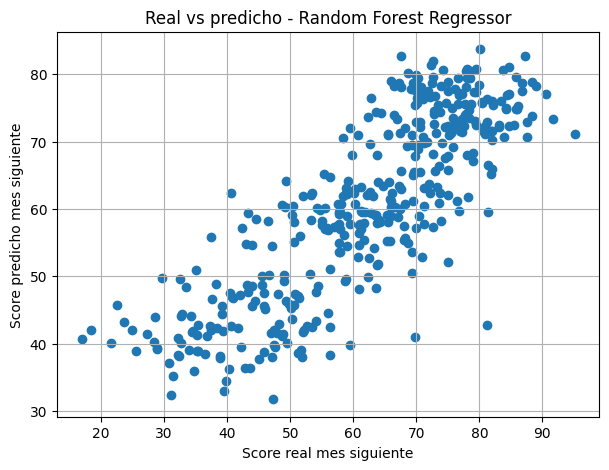

In [20]:

# Gráfico: real vs predicho
plt.figure(figsize=(7, 5))
plt.scatter(y_test, y_pred_final)
plt.xlabel('Score real mes siguiente')
plt.ylabel('Score predicho mes siguiente')
plt.title(f'Real vs predicho - {mejor_modelo_nombre}')
plt.grid(True)
plt.show()


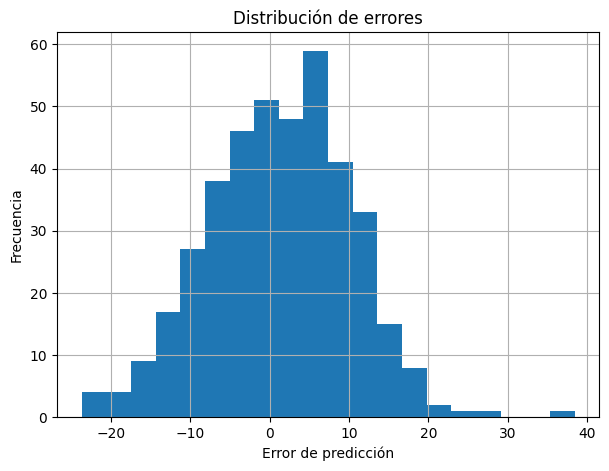

In [21]:

# Gráfico de errores
errores = y_test - y_pred_final
plt.figure(figsize=(7, 5))
plt.hist(errores, bins=20)
plt.xlabel('Error de predicción')
plt.ylabel('Frecuencia')
plt.title('Distribución de errores')
plt.grid(True)
plt.show()



## 5. Importancia de variables

Para modelos de árbol, se usa `feature_importances_`. Para modelos lineales, se usan coeficientes. Esto ayuda a explicar qué indicadores influyen más en la predicción del score del mes siguiente.


In [22]:

modelo_interno = modelo_final.named_steps['model']

if hasattr(modelo_interno, 'feature_importances_'):
    importancia = pd.DataFrame({
        'variable': features,
        'importancia': modelo_interno.feature_importances_
    }).sort_values('importancia', ascending=False)
elif hasattr(modelo_interno, 'coef_'):
    coef = np.ravel(modelo_interno.coef_)
    importancia = pd.DataFrame({
        'variable': features,
        'coeficiente': coef,
        'importancia_abs': np.abs(coef)
    }).sort_values('importancia_abs', ascending=False)
else:
    importancia = pd.DataFrame({'mensaje': ['El modelo seleccionado no expone importancia de variables.']})

importancia


,variable,importancia
4,nps_pct,0.399432
2,horas_conexion_acumulado,0.211483
10,nc_nps,0.168101
3,tmo_minutos,0.033205
1,horas_conexion_pct,0.029981
5,calidad_pct,0.027002
6,tipificacion_crm_pct,0.026903
11,nc_calidad,0.026817
12,nc_tipificacion,0.025193
9,nc_tmo,0.017275


In [23]:

# Guardar importancia de variables
output_importancia = DATA_DIR / 'importancia_variables_modelo_regresion.csv'
importancia.to_csv(output_importancia, index=False, encoding='utf-8-sig')
print('Archivo guardado:', output_importancia)


Archivo guardado: d:\INSTITUTO CONTINENTAL\4. CICLO - 4\BIG DATA APLICADA\PP2B_SATDPO\data\processed\importancia_variables_modelo_regresion.csv



## 6. Guardado del modelo

Se guarda el pipeline completo: imputación, escalamiento y modelo final de regresión. También se guarda metadata con las variables usadas y la regla de conversión de score a semáforo.


In [24]:

modelo_path = MODELS_DIR / 'modelo_regresion_score_semaforo.pkl'
metadata_path = MODELS_DIR / 'metadata_modelo_regresion_score_semaforo.pkl'

joblib.dump(modelo_final, modelo_path)

metadata = {
    'tipo_modelo': 'regresion_score',
    'modelo_final': mejor_modelo_nombre,
    'target_regresion': target_reg,
    'features': features,
    'regla_semaforo': {
        'Verde': 'score >= 100',
        'Ámbar': 'score >= 70 y score < 100',
        'Rojo': 'score < 70',
    },
    'metricas': resultados_df.iloc[0].to_dict(),
}

joblib.dump(metadata, metadata_path)

print('Modelo guardado en:', modelo_path)
print('Metadata guardada en:', metadata_path)


Modelo guardado en: d:\INSTITUTO CONTINENTAL\4. CICLO - 4\BIG DATA APLICADA\PP2B_SATDPO\models\modelo_regresion_score_semaforo.pkl
Metadata guardada en: d:\INSTITUTO CONTINENTAL\4. CICLO - 4\BIG DATA APLICADA\PP2B_SATDPO\models\metadata_modelo_regresion_score_semaforo.pkl
